**Uczenie Głębokie (laboratorium)**

Dominik Filipiak

`df[🏒]amu.edu.pl`

Materiały zawierają wybrane fragmenty materiałów pomocniczych, które przygotowałem na potrzeby kursu Deep Learning dla studentów kierunku Machine Learning na Wydziale Matematyki, Informatyki i Mechaniki UW.

Cześć kodu bazuje na [notebookach z kursu Deep Learning](https://github.com/mim-ml-teaching/public-dnn-2024-25) dla studentów kierunku Machine Learning na Wydziale Matematyki, Informatyki i Mechaniki UW.

# Głębokie sieci neuronowe

- DNN w pytorchu
- znikający/ekplodujący gradient
- pooling
- BatchNorm
- CNN
- augmentations
- dataloaders

In [1]:
import matplotlib
import matplotlib.pyplot as plt
from datetime import datetime
from functools import partial
from pathlib import Path
from typing import Optional
from tqdm import tqdm
from typing import Literal, Optional


import torch
import torch.nn as nn               # w uproszczeniu zawiera klasy stanowych obiektów (np. wartsw przechowujących gradient)
import torch.nn.functional as F     # w uproszczeniu bezstanowe operacje (np. relu, softmax)
import torch.optim as optim
from torch.utils.data import Subset
from torch.utils.tensorboard import SummaryWriter
from torchvision import datasets, transforms


matplotlib.style.use('dark_background')


## Zanikanie i Eksplozja Gradientów

Reguła łańcuchowa i powtarzane mnożenia przy złej inicjalizacji mogą prowadzić do zanikania lub eksplozji gradientów.
Stąd w poprzednim zadadniu analizowaliśmy inicjalizację Glorota.

### Przykład
Rozważmy sieć o 51 warstwach. Nawet niewielka różnica w wagach może prowadzić do ogromnych zmian w wynikach:
- $1.1^{51}$ rośnie wykładniczo.
- $0.9^{51}$ zmierza do zera.

## Dlaczego normalizujemy?
- **Wspólna skala**: Umożliwia porównywanie cech (np. wieku i wzrostu).
- **Szybsze trenowanie**: Choć sieć może się tego nauczyć, normalizacja przyspiesza uczenie i zmniejsza ryzyko utknięcia w złych minimach lokalnych.
- **Ułatwia regularyzację wag**: Pomaga w generalizacji modelu.
- **Stabilność numeryczna**: Zapobiega problemom z ekstremalnymi wartościami.

### Standaryzacja vs Normalizacja
- **Standaryzacja**: Odejmujemy średnią i dzielimy przez odchylenie standardowe:
  $$
  x' = \frac{x - \mu}{\sigma}
  $$
  gdzie $ \mu $ to średnia, a $ \sigma $ to odchylenie standardowe.
- **Skalowanie min-max**: Przekształca cechy do ustalonego zakresu (np. $[0,1]$):
  $$
  x' = \frac{x - x_{min}}{x_{max} - x_{min}}
  $$
  gdzie $ x_{min} $ i $ x_{max} $ to minimalna i maksymalna wartość danej cechy.

## Funkcje aktywacji i zanikanie gradientów

### Sigmoid (Logistyczna i Tanh)
- Sigmoid może **nasycać się**, co prowadzi do niemal zerowych gradientów.
- Przypomnijmy:
  - Pochodna sigmoidy: $ \sigma(1 - \sigma) $
  - Pochodna tanh: $ 1 - \tanh^2(x) $
- Gdy aktywacje są bliskie 0 lub 1, gradient jest prawie zerowy.
- Im głębsza sieć, tym mniejsze wartości gradientów.

### ReLU
- **Łagodzi problem zanikania gradientów**, choć nie całkowicie.
- Wprowadza **rzadkość aktywacji**, wspomagając regularyzację wag i lepsze uczenie cech.
- W przeciwieństwie do sigmoidy, wiele wartości aktywacji jest dokładnie zerowych, co sprzyja **odseparowaniu cech w reprezentacji danych**.
- **Oczekiwana wartość nie jest zerowa**, co nadal może powodować niestabilność w trenowaniu.



### Przygotowanie

In [2]:
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_val_dataset = datasets.MNIST('../data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('../data', train=False, transform=transform)

train_dataset = Subset(train_val_dataset, indices=range(0, 55_000))
val_dataset = Subset(train_val_dataset, indices=range(55_000, 60_000))


In [3]:
def train_epoch(
        model: torch.nn.Module,
        device: torch.device,
        train_loader: torch.utils.data.DataLoader,
        optimizer: torch.optim.Optimizer,
        epoch: int,
        writer: Optional[SummaryWriter] = None,
        ):
    """Epoka treningu.

    Args:
        model (torch.nn.Module): Model który trenujemy.
        device (torch.device): Urządzenie na którym trenujemy.
        train_loader (torch.utils.data.DataLoader): `DataLoader` z danymi do trenowania.
        optimizer (torch.optim.Optimizer): Algorytm optymalizacji.
        epoch (int): Nr epoki (na potrzeby logowania)
        writer (SummaryWriter, optional): Opcjonalny obiekt do logów tensorboard.
    """

    model.train()
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)       # przenosimy dane na urządzenie (np. CPU, GPU, MPS...)
        optimizer.zero_grad()                                   # zerujemy gradient
        output = model(data)                                    # feed-forward
        loss = F.cross_entropy(output, target)                  # obliczenie aktualnego kosztu
        loss.backward()                                         # liczmy gradienty propagacją wsteczną
        optimizer.step()                                        # aktaulizacja wag (np. krok w SGD)

    if writer:
        writer.add_scalar("train/loss", loss.detach().cpu().item(), epoch)

In [4]:
def _val_or_test_epoch(
        model: torch.nn.Module,
        device: torch.device,
        test_loader: torch.utils.data.DataLoader,
        val_or_test: Literal["val", "test"],
        epoch: Optional[int] = None,
        writer: Optional[SummaryWriter] = None
        ) -> float:
    """Epoka ewaluacji (walidacja lub test). Zwraca koszt.

    Args:
        model (torch.nn.Module): Model który trenujemy.
        device (torch.device): Urządzenie na którym trenujemy.
        test_loader (torch.utils.data.DataLoader): `DataLoader` z danymi do ewaluacji.
        val_or_test (Literal): `"val"` dla walidacji, `"test"` dla testu.
        epoch (int, optional): Nr epoki (na potrzeby logowania)
        writer (SummaryWriter, optional): Opcjonalny obiekt do logów tensorboard.
    """
    
    model.eval()    # ustawiamy model w tryb ewaluacji
    test_loss = 0
    correct = 0
    with torch.no_grad():   # nie liczymy gradientów
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.cross_entropy(output, target, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)               # indeks najbardziej prawdopodobnej kategorii
            correct += pred.eq(target.view_as(pred)).sum().item()   # liczba poprawnych predykcji

        test_loss /= len(test_loader.dataset)
        accuracy = 100. * correct / len(test_loader.dataset)

        if writer:
            writer.add_scalar(f"{val_or_test}/loss", test_loss, epoch)
            writer.add_scalar(f"{val_or_test}/accuracy", accuracy, epoch)
    
    return test_loss

val_epoch = partial(_val_or_test_epoch, val_or_test="val")
test_epoch = partial(_val_or_test_epoch, val_or_test="test")

Ustalmy hiperparametry oraz zmienne pomocnicze.

In [5]:
def get_torch_device() -> torch.device:
    """Funkcja pomocnicza do określenia na którym urządzeniu będziemy wykonywać obliczenia."""
    if torch.cuda.is_available():
        return torch.device("cuda") # NVIDIA GPU
    elif torch.backends.mps.is_available():
        return torch.device("mps")  # Apple Silicon - uwaga, nie wszysko działa. W razie kłopotów przejdź na CPU.
    else:
        return torch.device("cpu")  # CPU

In [6]:
seed = 1
device = get_torch_device()

batch_size = 256
test_batch_size = 1000
epochs = 20
learning_rate = 1e-2

In [7]:
torch.manual_seed(seed)

train_kwargs = {'batch_size': batch_size}
test_kwargs = {'batch_size': test_batch_size}

if torch.cuda.is_available():
    cuda_kwargs = {'num_workers': 1,
                    'pin_memory': True,
                    'shuffle': True}
    train_kwargs.update(cuda_kwargs)
    test_kwargs.update(cuda_kwargs)

Do ładowania automatycznego danych w batchach przyda się `DataLoader`.

In [8]:
train_loader = torch.utils.data.DataLoader(train_dataset,**train_kwargs)
val_loader = torch.utils.data.DataLoader(val_dataset, **test_kwargs)
test_loader = torch.utils.data.DataLoader(test_dataset, **test_kwargs)

## BatchNorm

Batch Normalization (BatchNorm) to technika stosowana w sieciach neuronowych w celu przyspieszenia uczenia i stabilizacji procesu optymalizacji. Normalizuje ona wejścia do każdej warstwy w sieci, co zmniejsza problem znikającego i eksplodującego gradientu oraz pozwala na użycie większych współczynników uczenia.  

Dla danej warstwy sieci neuronowej, BatchNorm wykonuje następujące operacje na wejściu $\mathbf{x}$:  

1. **Obliczenie średniej i wariancji** dla mini-batcha:  
   $$
   \mu_B = \frac{1}{m} \sum_{i=1}^{m} x_i, \quad
   \sigma_B^2 = \frac{1}{m} \sum_{i=1}^{m} (x_i - \mu_B)^2
   $$  
   gdzie $m$ to liczba próbek w mini-batchu.  

2. **Normalizacja danych wejściowych**:  
   $$
   \hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}
   $$  
   gdzie $\epsilon$ to niewielka wartość zapobiegająca dzieleniu przez zero.  

3. **Transformacja afiniczna** (skalowanie i przesunięcie):  
   $$
   y_i = \gamma \hat{x}_i + \beta
   $$  
   gdzie $\gamma$ i $\beta$ to parametry uczone przez sieć, które pozwalają na dopasowanie rozkładu danych wejściowych.  

Podczas trenowania sieci przechowuje się wartości średnich i wariancji z mini-batchy, które są następnie wykorzystywane w trybie inferencji:  
   $$
   \mu \approx \text{running mean}, \quad \sigma^2 \approx \text{running variance}
   $$  

Batch Normalization pozwala na stabilizację procesu uczenia, umożliwia stosowanie większych wartości współczynnika uczenia oraz zmniejsza zależność od początkowej inicjalizacji wag.

Dla chętnych: [wyjaśnienie dlaczego to działa](https://arxiv.org/pdf/1502.03167).

In [9]:
class BatchNorm(torch.nn.Module):
    def __init__(self, num_features):
        super(BatchNorm, self).__init__()
        
        self.num_features = num_features
        self.momentum = 0.1
        self.eps = 1e-5
        
        self.gamma = nn.Parameter(torch.Tensor(num_features))
        self.beta = nn.Parameter(torch.Tensor(num_features))
        
        self.running_var = torch.Tensor(num_features)
        self.running_mean = torch.Tensor(num_features)
        
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.zeros_(self.beta)
        nn.init.ones_(self.gamma)
        nn.init.zeros_(self.running_mean)
        nn.init.zeros_(self.running_var)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert x.shape[0], 'Batch size must be bigger than 1'
        
        if self.training:
            var, mean = torch.var_mean(x, dim=0)
            self.running_var = self.running_var * self.momentum + var * (1 - self.momentum)
            self.running_mean = self.running_mean * self.momentum + mean * (1 - self.momentum)
        else:
            mean = self.running_mean
            var = self.running_var

        mean = mean.unsqueeze(0)
        var = var.unsqueeze(0)

        x = (x - mean) / torch.sqrt(var + self.eps)
        x = x * self.gamma + self.beta

        return x


...w praktyce wykorzysta się raczej gotową implementację (np. [to](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html)).

In [10]:
class DeepNet(nn.Module):
    def __init__(self, num_hidden_layers: int, use_batch_norm=False):
        super(DeepNet, self).__init__()

        self.linear_layers = torch.nn.ModuleList(
            [nn.Linear(784, 64)] +
            [nn.Linear(64, 64) for _ in range(num_hidden_layers)]
        )
        
        if use_batch_norm:
            batch_norm_or_identity = BatchNorm(64)
        else:
            batch_norm_or_identity = nn.Identity()
        
        self.batch_norms = torch.nn.ModuleList([
            batch_norm_or_identity for _ in range(num_hidden_layers + 1)
        ])
        self.last_linear = nn.Linear(64, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(-1, 28 * 28)
        for linear, batch_norm in zip(self.linear_layers, self.batch_norms):
            x = F.relu(batch_norm(linear(x)))
        x = self.last_linear(x)
        return x

Porównajmy teraz jak uczą się nasze sieci z i bez BN.
Zwróć uwagę, ze tym razem zapisujemy najlepsze wagi.

In [11]:
device = torch.device('cpu')
epochs = 20

for num_hidden_layers in [3, 5, 10]:
    for use_batch_norm in [True, False]:

        run_name = f"dnn_{num_hidden_layers}{'-bn' if use_batch_norm else ''}_lr{learning_rate}_{str(datetime.now().timestamp())}"

        model = DeepNet(num_hidden_layers=num_hidden_layers).to(device)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)

        best_val_loss = torch.inf
        with SummaryWriter(Path("runs") / run_name) as writer:
            for epoch in tqdm(range(0, epochs), desc=run_name):
                train_epoch(model, device, train_loader, optimizer, epoch, writer)
                current_val_loss = val_epoch(model, device, test_loader, epoch=epoch, writer=writer)
                
                if current_val_loss < best_val_loss:
                    best_params = model.state_dict()

            model.load_state_dict(best_params)

            test_loss = test_epoch(model, device, test_loader, epoch=epoch, writer=writer)

            writer.add_hparams(
                {
                    "num_hidden_layers": num_hidden_layers,
                    "use_batch_norm": use_batch_norm,
                    "epochs": epochs,
                    "learning_rate": learning_rate,
                },
                {'hparam/loss': test_loss},
                run_name=run_name)

dnn_3_lr0.01_1743867790.73298:  50%|█████     | 10/20 [10:25<10:25, 62.54s/it]


KeyboardInterrupt: 

## Splot (ang. convolution)

Splot (dalej jako nieco nieformalnie *konwolucja*) jest jedną z podstawowych operacji stosowanych w sieciach neuronowych do ekstrakcji cech z danych wejściowych, takich jak obrazy.
W klasycznej definicji, konwolucja dla funkcji ciągłych jest zdefiniowana jako:  

$$
(f \star g)(t) = \int_{-\infty}^{\infty} f(\tau) g(t - \tau) d\tau
$$

Jednak w kontekście sieci neuronowych pracujemy zazwyczaj z konwolucją dyskretną:

$$
(f * g)[n] = \sum_{m=-\infty}^{\infty} f[m] g[n - m]
$$

Tak naprawdę w implementacji PyTorch konwolucja jest obliczana jako korelacja krzyżowa, ponieważ dla celów uczenia operacja ta daje te same wyniki, ale nie wymaga odwracania jądra.  

Tym samym, dla obrazu $ I $ oraz jądra konwolucyjnego $ K $, operacja konwolucji w PyTorch jest opisana jako:

$$
(I * K)(i, j) = \sum_{m} \sum_{n} I(i + m, j + n) \cdot K(m, n)
$$

Gdzie:
- $ (I * K)(i, j) $ to wartość w pozycji $ (i, j) $ na mapie cech,
- $ I(i + m, j + n) $ to wartość piksela obrazu wejściowego,
- $ K(m, n) $ to wartość jądra konwolucyjnego.

Podczas implementacji w PyTorch konwolucję można wykonać za pomocą:  

$$
\texttt{torch.nn.Conv2d}\left({C_{in}, C_{out}, k, s, p, d}\right)
$$

Gdzie:
- $ C_{in} $ - liczba kanałów wejściowych,
- $ C_{out} $ - liczba kanałów wyjściowych,
- $ k $ - rozmiar jądra konwolucyjnego,
- $ s $ - krok przesuwania (stride),
- $ p $ - padding (dodatkowe piksele dodane do krawędzi obrazu),
- $ d $ - dillation (rozszerzenie jądra, które tworzy efekt „sita”).  

Definicja operacji konwolucyjnej w PyTorch:  

$$
\texttt{torch.nn.Conv2d} \left( {N_i, C_{\text{out}_j}} \right) = \text{bias}(C_{\text{out}_j}) + \sum_{k = 0}^{C_{\text{in}} - 1} \text{weight}(C_{\text{out}_j}, k) \star \text{input}(N_i, k)
$$

Konwolucję można efektywnie obliczać na różne sposoby, m.in. w dziedzinie częstotliwości, gdzie operacja sprowadza się do mnożenia w przestrzeni Fouriera.  

#### Warianty konwolucji:
- **Dilated Convolutions** – działają jak sito, rozszerzając pole recepcyjne bez zwiększania liczby parametrów.
- **Transposed Convolutions** – stosowane do generowania obrazów.
- **Depthwise Separable Convolutions** – pozwalają na redukcję liczby parametrów.

In [12]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv_layers = torch.nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(),
            nn.Flatten(),
        )

        self.head = torch.nn.Sequential(
            nn.Linear(7 * 7 * 32, 200),
            nn.BatchNorm1d(200),
            nn.ReLU(),
            nn.Linear(200, 10),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.head(x)
        return x

In [13]:
device = torch.device('cpu')
epochs = 20


run_name = f"cnn_lr{learning_rate}_{str(datetime.now().timestamp())}"

model = ConvNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

best_val_loss = torch.inf
with SummaryWriter(Path("runs") / run_name) as writer:
    for epoch in tqdm(range(0, epochs), desc=run_name):
        train_epoch(model, device, train_loader, optimizer, epoch, writer)
        current_val_loss = val_epoch(model, device, test_loader, epoch=epoch, writer=writer)
        
        if current_val_loss < best_val_loss:
            best_params = model.state_dict()

    model.load_state_dict(best_params)

    test_loss = test_epoch(model, device, test_loader, epoch=epoch, writer=writer)

    writer.add_hparams(
        {
            "num_hidden_layers": num_hidden_layers,
            "use_batch_norm": use_batch_norm,
            "epochs": epochs,
            "learning_rate": learning_rate,
        },
        {'hparam/loss': test_loss},
        run_name=run_name)

cnn_lr0.01_1743868423.671767: 100%|██████████| 20/20 [40:15<00:00, 120.75s/it]


In [15]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

count_params(model)

321106

## GradCam

Poczytaj więcej [tutaj](https://github.com/jacobgil/pytorch-grad-cam).

In [23]:
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

test_dataset = datasets.MNIST(root='./data', train=False, transform=transforms.ToTensor(), download=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=True)

image, label = next(iter(test_loader))
image_np = image.squeeze().numpy()

target_layers = [model.conv_layers[-2]]  # Ostatnia warstwa konwolucyjna
cam = GradCAM(model=model, target_layers=target_layers)
targets = [ClassifierOutputTarget(label)]

gradcam_map = cam(input_tensor=image, targets=targets)
gradcam_map = gradcam_map.squeeze()

image_rgb = np.repeat(image_np[:, :, np.newaxis], 3, axis=2)  # Konwersja obrazu do formatu RGB

gradcam_image = show_cam_on_image(image_rgb, gradcam_map, use_rgb=True)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image_np, cmap='gray')
ax[0].set_title("Oryginalny obraz")
ax[0].axis('off')

ax[1].imshow(gradcam_image)
ax[1].set_title("Grad-CAM")
ax[1].axis('off')

plt.show()

ModuleNotFoundError: No module named 'pytorch_grad_cam'

# Zadania do samodzielnego rozwiązania

### Z1. CNN 
Dla zadania z lab. 2 ([`plantvillage-dataset`](https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset)) tym razem napisz konwolucyjną sieć neuronową.

- Napisz swój PyTorchowy dataset i dataloader - jak to zrobisz dowiesz się [stąd](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html).
- Porównaj wyniki CNN ze "starym" podejściem z lab. 2.

In [25]:
import os
import pandas as pd
from torch.utils.data import Dataset
from torchvision.io import read_image
from skimage.io import imread


class PlantVillageDataset(Dataset):
    def __init__(self, base_dir, class_names, train = True,
                 transform=None, target_transform=None):
        self.train_imgs = []
        self.labels = []

        for class_idx, class_name in enumerate(class_names):
            dir_name = base_dir + class_name
            for filename in os.listdir(dir_name):
                full_path = os.path.join(dir_name, filename)
                img = imread(full_path)
                self.train_imgs.append(img)
                self.labels.append(class_idx)

        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.train_imgs[idx]
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

In [26]:
import torchvision.transforms as transforms

base_dir = "../plantvillage dataset/grayscale/"
class_names = ["Blueberry___healthy", "Grape___healthy"]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((64, 64)),
])

pv_dataset = PlantVillageDataset(base_dir, class_names,
                                       transform=transform)

In [33]:
len(pv_dataset)

1925

In [34]:
train_dataset = Subset(pv_dataset, indices=range(0, 1500))
val_dataset = Subset(pv_dataset, indices=range(1500, 1750))
test_dataset = Subset(pv_dataset, indices=range(1750, 1925))

In [35]:
train_loader = torch.utils.data.DataLoader(train_dataset,**train_kwargs)
val_loader = torch.utils.data.DataLoader(val_dataset, **test_kwargs)
test_loader = torch.utils.data.DataLoader(test_dataset, **test_kwargs)

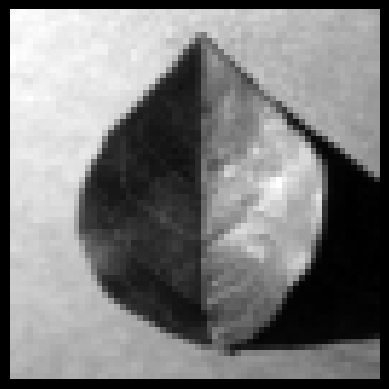

In [38]:
img = pv_dataset[1500][0].squeeze(0)
img = img.detach().cpu().numpy()

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

In [39]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv_layers = torch.nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(),
            nn.Flatten(),
        )

        self.head = torch.nn.Sequential(
            nn.Linear(7 * 7 * 32, 200),
            nn.BatchNorm1d(200),
            nn.ReLU(),
            nn.Linear(200, 2),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.head(x)
        return x

In [ ]:
device = torch.device('cuda')
epochs = 10


run_name = f"cnn_lr{learning_rate}_{str(datetime.now().timestamp())}"

model = ConvNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

best_val_loss = torch.inf
with SummaryWriter(Path("runs") / run_name) as writer:
    for epoch in tqdm(range(0, epochs), desc=run_name):
        train_epoch(model, device, train_loader, optimizer, epoch, writer)
        current_val_loss = val_epoch(model, device, test_loader, epoch=epoch, writer=writer)

        if current_val_loss < best_val_loss:
            best_params = model.state_dict()

    model.load_state_dict(best_params)

    test_loss = test_epoch(model, device, test_loader, epoch=epoch, writer=writer)

    writer.add_hparams(
        {
            "num_hidden_layers": num_hidden_layers,
            "use_batch_norm": use_batch_norm,
            "epochs": epochs,
            "learning_rate": learning_rate,
        },
        {'hparam/loss': test_loss},
        run_name=run_name)

cnn_lr0.01_1743879357.053447:   0%|          | 0/10 [00:00<?, ?it/s]


### Z2. Augmentations

Do treningu z poprzedniego zadania dodaj co najmniej 2 transformacje (tzw. augmentations - np. obroty, wycięcia...).
Przeczytasz o nich więcej [tutaj](https://pytorch.org/vision/stable/transforms.html).
- Zwizualizuj wpływ transformacji na wejściowy obraz.
- Zbadaj ich wpływ na metryki.